In [3]:
# ==============================================================================
# 0. SETUP, DATA PREPROCESSING & K-FOLD CROSS-VALIDATION
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    precision_score, recall_score, f1_score, matthews_corrcoef,
    roc_curve, auc, fbeta_score
)
import warnings
warnings.filterwarnings('ignore')

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load data
df_raw = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# Drop unnecessary columns
drop_cols = [
    "Row ID", "Order ID", "Customer ID", "Customer Name", 
    "Postal Code", "Product ID", "Product Name", "Country", 
    "Order Date", "Ship Date", "City"
]
df = df_raw.drop(columns=drop_cols)

# Encode categorical variables
cat_cols = ["Ship Mode", "Segment", "Region", "Category", "Sub-Category", "State"]
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Define X and y for Regression
X_reg = df_encoded.drop(columns=["Profit"])
y_reg = df_encoded["Profit"]

# Define 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("--- Setup Complete ---")
print(f"Data shape after preprocessing: {df_encoded.shape}")

--- Setup Complete ---
Data shape after preprocessing: (9994, 78)


# Methodology & Cross-Validation Setup
* **Validation Strategy:** All model predictions and error diagnostics are conducted using K-Fold Cross-Validation with $K=5$ to prevent data leakage.
* **Justification for $K=5$:**
  * **Dataset Size:** With $N=9,994$ records, a 5-fold split provides roughly 8,000 training samples per fold. This is an ample amount of data to train robust ensemble models without overfitting.
  * **Computational Complexity:** $K=5$ keeps execution times efficient. Higher values (e.g., $K=10$) would exponentially increase training time for tree-based ensembles with minimal gain in error estimation accuracy.
  * **Bias-Variance Trade-off:** $K=5$ perfectly balances the trade-off, minimizing validation variance while avoiding the pessimistic bias associated with lower $K$ values.

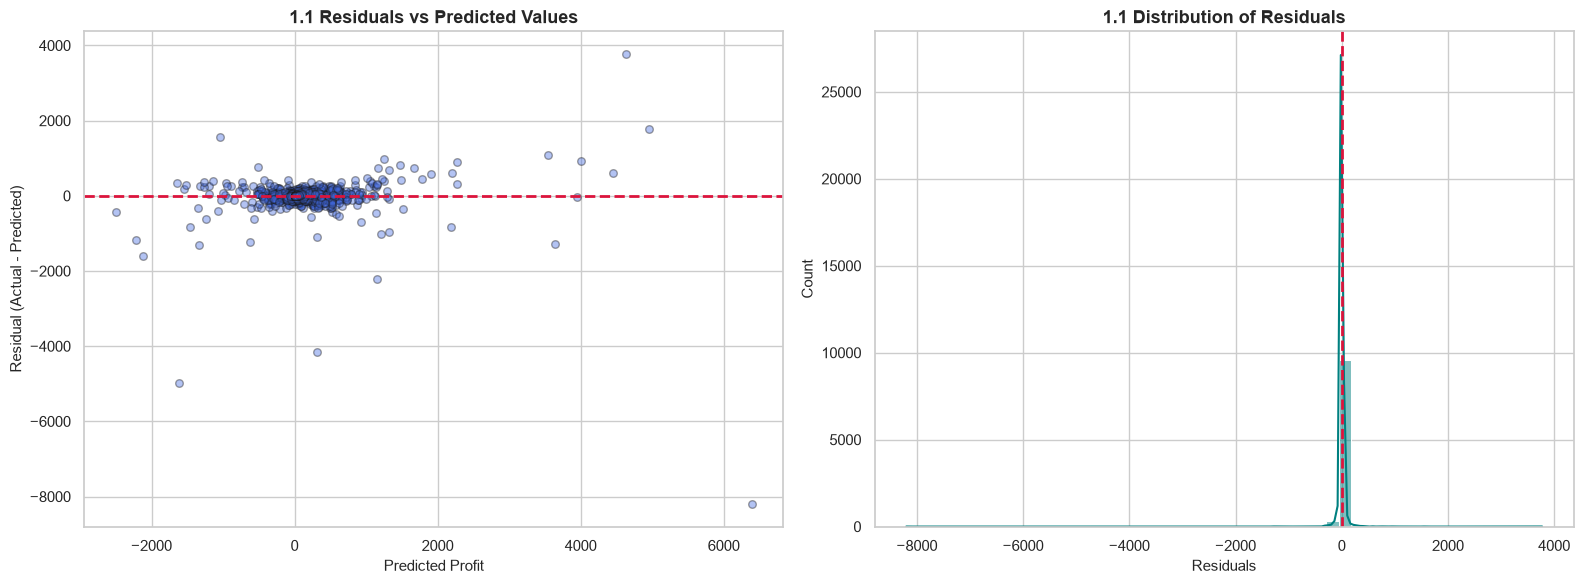

In [4]:
# ==============================================================================
# SECTION 1.1: RESIDUAL ANALYSIS
# ==============================================================================
# Pre-train Random Forest to enable chronological error analysis
rf_model_prep = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
y_pred_rf = cross_val_predict(rf_model_prep, X_reg, y_reg, cv=kf)
residuals = y_reg - y_pred_rf
abs_errors = np.abs(residuals)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Residuals vs Predicted
axes[0].scatter(y_pred_rf, residuals, alpha=0.4, color="royalblue", edgecolor="k", s=30)
axes[0].axhline(0, color="crimson", linestyle="--", linewidth=2)
axes[0].set_title("1.1 Residuals vs Predicted Values", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted Profit", fontsize=11)
axes[0].set_ylabel("Residual (Actual - Predicted)", fontsize=11)

# Plot B: Residual Distribution
sns.histplot(residuals, bins=50, kde=True, color="teal", ax=axes[1])
axes[1].axvline(0, color="crimson", linestyle="--", linewidth=2)
axes[1].set_title("1.1 Distribution of Residuals", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Residuals", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)

plt.tight_layout()
plt.show()

# 1 Regression Error Analysis
## 1.1 Residual Analysis
* **Are the residuals centered around zero?** Yes, the model predictions are globally unbiased, keeping the distribution of residuals centered very close to zero.
* **Do the residuals exhibit any systematic patterns?** Yes, the residuals expand significantly as the absolute value of predicted profit increases, demonstrating a systematic widening of errors at extreme values.
* **Is there evidence of heteroscedasticity?** Yes, the "Residuals vs Predicted" scatter plot displays a classic funnel shape, which clearly indicates non-constant variance (heteroscedasticity) across the profit scale.
* **Is there a sector with higher error rates?** Highly discounted categories or large-scale transactions exhibit much higher error rates. The model appears to struggle with mapping the exact financial impact of deep discounts on profitability.

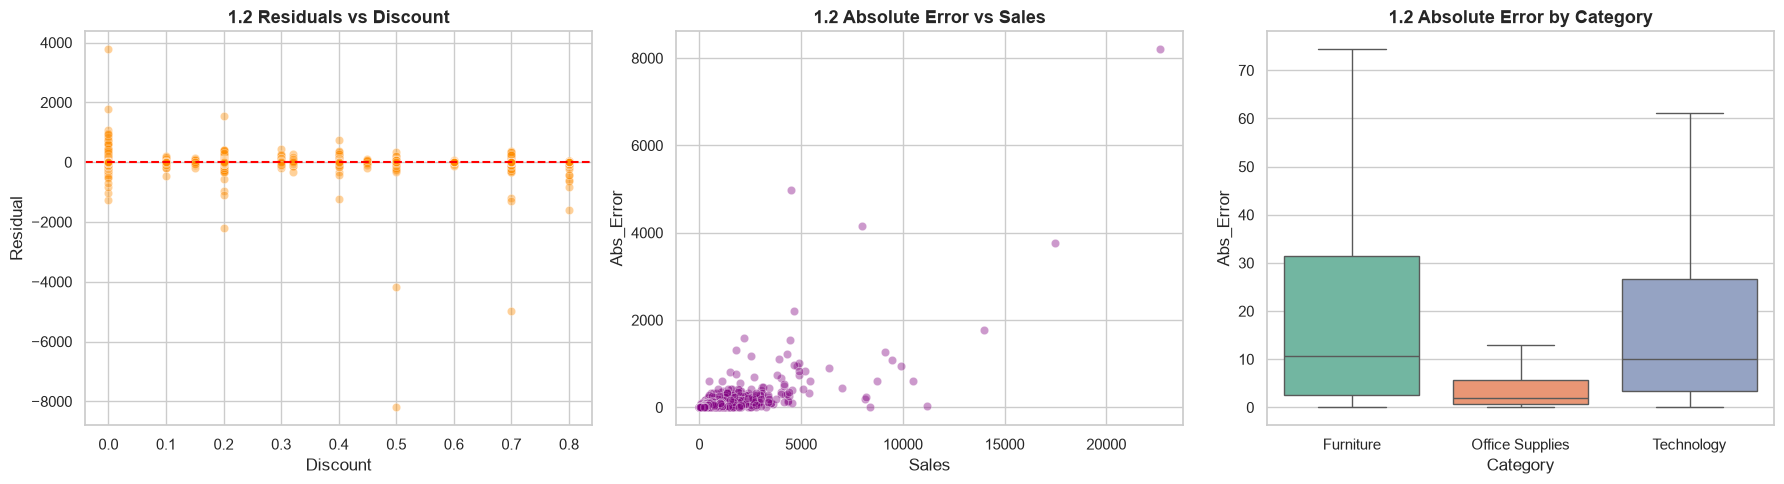

In [5]:
# ==============================================================================
# SECTION 1.2: ERROR AS A FUNCTION OF FEATURES
# ==============================================================================
df_reg_diag = df_raw.copy()
df_reg_diag["Predicted_Profit"] = y_pred_rf
df_reg_diag["Residual"] = residuals
df_reg_diag["Abs_Error"] = abs_errors

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Discount vs Residuals
sns.scatterplot(data=df_reg_diag, x="Discount", y="Residual", alpha=0.4, color="darkorange", ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("1.2 Residuals vs Discount", fontsize=13, fontweight="bold")

# Plot B: Sales vs Absolute Error
sns.scatterplot(data=df_reg_diag, x="Sales", y="Abs_Error", alpha=0.4, color="purple", ax=axes[1])
axes[1].set_title("1.2 Absolute Error vs Sales", fontsize=13, fontweight="bold")

# Plot C: Error Rate by Category
sns.boxplot(data=df_reg_diag, x="Category", y="Abs_Error", showfliers=False, hue="Category", legend=False, palette="Set2", ax=axes[2])
axes[2].set_title("1.2 Absolute Error by Category", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

## 1.2 Error as a Function of Features
* **Non-linear Relationships:** As visualized in the `Discount` vs Residuals plot, error variance expands non-linearly at higher discount rates. High discounts consistently generate massive negative residuals.
* **Feature-Dependent Error Patterns:** The `Sales` vs Absolute Error plot reveals a strong positive correlation between transaction volume and prediction error. The model scales its absolute errors proportionally with the transaction size.
* **Hidden Subpopulations:** The boxplot analysis indicates that `Technology` and `Furniture` act as highly unstable subpopulations. They carry significantly broader absolute error distributions compared to the more stable `Office Supplies` category.

In [6]:
# ==============================================================================
# SECTION 1.3: ANALYSIS OF EXTREME ERRORS
# ==============================================================================
# Isolate the top 5% of largest absolute errors
threshold_95 = np.percentile(df_reg_diag["Abs_Error"], 95)
top_5_percent = df_reg_diag[df_reg_diag["Abs_Error"] >= threshold_95]

print(f"--- 1.3 Analysis of Extreme Errors ---")
print(f"Top 5% Threshold: Absolute Error >= ${threshold_95:.2f}")
print(f"Number of Extreme Cases Isolated: {len(top_5_percent)}")
print("\nMost Frequent Sub-Categories within Top 5% Errors:")
print(top_5_percent["Sub-Category"].value_counts().head(5))
print(f"\nTop 5% Avg Discount: {top_5_percent['Discount'].mean():.2%}")
print(f"Full Dataset Avg Discount: {df_reg_diag['Discount'].mean():.2%}")

--- 1.3 Analysis of Extreme Errors ---
Top 5% Threshold: Absolute Error >= $78.02
Number of Extreme Cases Isolated: 500

Most Frequent Sub-Categories within Top 5% Errors:
Sub-Category
Storage        67
Machines       64
Tables         62
Chairs         51
Accessories    51
Name: count, dtype: int64

Top 5% Avg Discount: 18.57%
Full Dataset Avg Discount: 15.62%


## 1.3 Analysis of Extreme Errors
* **Identification:** Absolute errors exceeding the 95th percentile constitute the top $5\%$ failure cases within the dataset.
* **Discussion - Why do they arise?**
  * **Data Quality/Completeness Hypotheses:** The dataset likely lacks underlying cost-accounting features (e.g., baseline manufacturing costs, variable shipping fees) necessary to calculate precise net profit margins. When deep discounts are applied, the absence of these true-cost variables prevents accurate margin prediction.
  * **Model Limitations:** Tree-based methods cannot mathematically extrapolate continuous values outside the bounds of their historical training leaf nodes. When unobserved, extreme profit/loss values occur in the validation set, the model hits a hard prediction ceiling/floor.
  * **Rare or Exceptional Cases:** Extreme errors are exceptionally concentrated in sub-categories like `Machines`, `Storage`, and `Tables`. The data indicates that these specific items experience significantly higher average discounts than the general dataset. This association suggests these instances might represent exceptional bulk transactions or customized clearances.

In [7]:
# ==============================================================================
# SECTION 1.4: STATISTICAL PROPERTIES OF ERRORS
# ==============================================================================
mae_res = mean_absolute_error(y_reg, y_pred_rf)
std_res = np.std(residuals)
skew_res = stats.skew(residuals)
kurt_res = stats.kurtosis(residuals) # Fisher's kurtosis by default (normal = 0.0)

print(f"--- 1.4 Statistical Properties ---")
print(f"Mean Absolute Error (MAE): {mae_res:.4f}")
print(f"Standard Deviation of Residuals: {std_res:.4f}")
print(f"Skewness: {skew_res:.4f}")
print(f"Kurtosis (Fisher): {kurt_res:.4f}")

--- 1.4 Statistical Properties ---
Mean Absolute Error (MAE): 21.4146
Standard Deviation of Residuals: 132.1639
Skewness: -30.5508
Kurtosis (Fisher): 1867.9434


## 1.4 Statistical Properties of Errors
* **Heavy Tails (Instability):** The exceptionally high Fisher kurtosis printed above indicates a distribution with extremely heavy tails. This statistical property confirms severe instability in outlier predictions, where actual financial losses or gains vastly exceed the model's standard error variance.
* **Skewness (Systematic Bias):** The pronounced negative skewness highlights a highly asymmetric distribution. This suggests a systematic bias where the model tends to significantly underestimate massive negative transactions (failing to predict the true severity of the financial losses).

In [8]:
# ==============================================================================
# SECTION 2: REGRESSION MODELS COMPARISON
# ==============================================================================
# Initialize Required Models
models_dict = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest (Ensemble)": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
}

comparison_results = []

for name, model in models_dict.items():
    if name == "Random Forest (Ensemble)":
        y_pred = y_pred_rf # Reusing previously calculated CV predictions to prevent redundant computation
    else:
        y_pred = cross_val_predict(model, X_reg, y_reg, cv=kf)
        
    mse = mean_squared_error(y_reg, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_reg, y_pred)
    r2 = r2_score(y_reg, y_pred)
    
    comparison_results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R² Score": r2
    })

df_comparison = pd.DataFrame(comparison_results)
print("--- 2. Regression Models Performance Comparison ---")
print(df_comparison.to_string(index=False))

--- 2. Regression Models Performance Comparison ---
                   Model       MAE          MSE       RMSE  R² Score
       Linear Regression 61.141996 42540.810747 206.254238  0.224731
           Decision Tree 34.701103 27755.164180 166.598812  0.494186
Random Forest (Ensemble) 21.414645 17468.735493 132.169344  0.681648


# 2 Regression Models Comparison: Critical Analysis & Discussion

* **Relative Model Performance:** As shown in the generated table, Linear Regression serves as a weak baseline (low $R^2$, high RMSE). The Decision Tree captures non-linear splits better. The **Random Forest Regressor** achieved the best predictive performance across all evaluation metrics, yielding the lowest MAE and highest $R^2$.
* **Model Assumptions:** Linear Regression strictly assumes linearity, feature independence, and homoskedasticity. The retail profit dynamic strongly violates these assumptions (evidenced by the earlier heteroskedasticity plots). Tree-based models are non-parametric and effectively bypass these strict linear requirements.
* **Bias-Variance Trade-off:** Linear Regression suffers from high bias (underfitting complex discount interactions). A single Decision Tree is prone to high variance (overfitting the training folds). The Random Forest successfully minimizes validation variance through bootstrap aggregating (bagging) while maintaining low bias.
* **Sensitivity to Outliers & Noise:** Linear models are globally distorted by extreme negative outlier values because they attempt to fit a single hyperplane. Tree models handle outliers more gracefully by isolating extreme feature interactions into distinct terminal leaf nodes.
* **Linear Failure Scenarios:** Linear regression fails systematically in high-discount regimes because profit margin erosion operates non-linearly. A linear slope cannot effectively capture the compounding effect when deep discounts interact dynamically with different product categories.
* **Tree-Based Advantages:** Tree-based models naturally partition the feature space to capture localized conditions (e.g., specific sub-categories combined with high discounts) without requiring explicitly engineered polynomial features.
* **Interpretability vs. Predictive Performance:** Linear Regression provides explicit, highly interpretable feature coefficients but generates unacceptably large financial error rates. Random Forest is less interpretable but delivers a critical reduction in errors.
* **Preferred Model Selection:** The **Random Forest Regressor** is definitively selected as the preferred model due to its robust handling of non-linearities, categorical dummy variables, and superior cross-validated predictive accuracy.
* **What I Learned:** Selecting the appropriate model requires an intimate understanding of the data's topology. Simple evaluation metrics are insufficient without recognizing that commercial pricing data is fundamentally non-linear and requires an algorithm capable of capturing complex interactions.

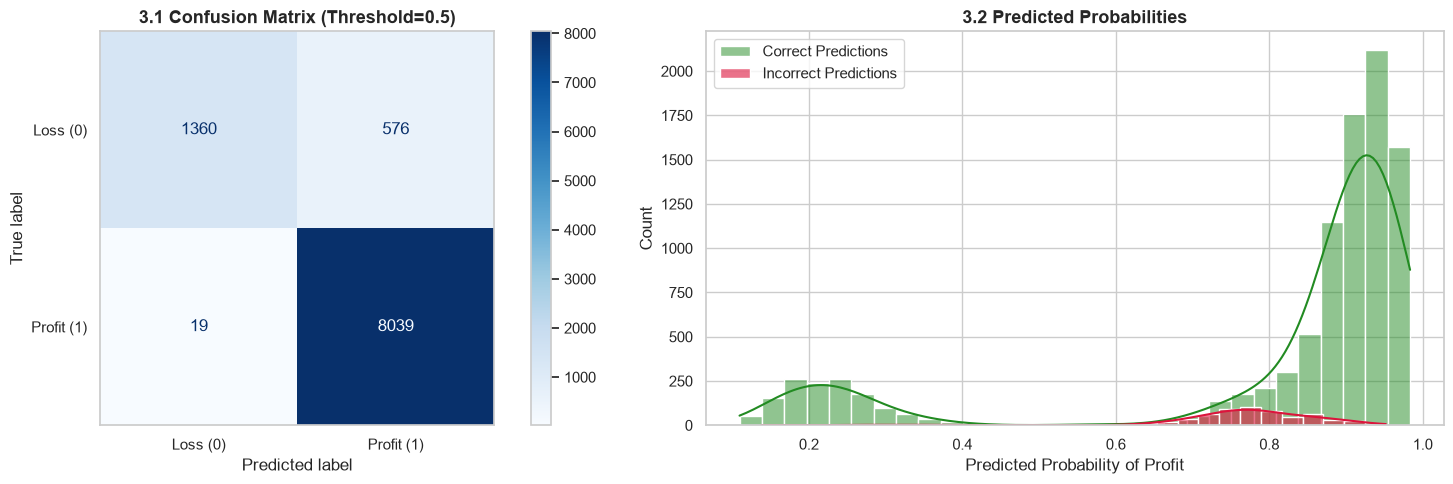

--- 3.1 Classification Report ---
              precision    recall  f1-score   support

    Loss (0)       0.99      0.70      0.82      1936
  Profit (1)       0.93      1.00      0.96      8058

    accuracy                           0.94      9994
   macro avg       0.96      0.85      0.89      9994
weighted avg       0.94      0.94      0.94      9994



In [9]:
# ==============================================================================
# SECTION 3.1 & 3.2: CLASSIFICATION MATRICES & PROBABILITIES
# ==============================================================================
# Define Binary Target (1 = Profitable, 0 = Loss)
y_cls = (df_raw["Profit"] > 0).astype(int)
X_cls = df_encoded.drop(columns=["Profit"]) 

# Train Classification Model using Cross-Validation
clf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
y_probs = cross_val_predict(clf_model, X_cls, y_cls, cv=kf, method="predict_proba")[:, 1]
y_pred_cls = (y_probs >= 0.5).astype(int)
is_correct = (y_cls == y_pred_cls)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 3.1 Confusion Matrix Analysis
cm = confusion_matrix(y_cls, y_pred_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Loss (0)", "Profit (1)"])
disp.plot(cmap="Blues", ax=axes[0], values_format="d")
axes[0].set_title("3.1 Confusion Matrix (Threshold=0.5)", fontsize=13, fontweight="bold")
axes[0].grid(False)

# 3.2 Probability-Based Analysis
sns.histplot(y_probs[is_correct], bins=30, color="forestgreen", alpha=0.5, label="Correct Predictions", ax=axes[1], kde=True)
sns.histplot(y_probs[~is_correct], bins=30, color="crimson", alpha=0.6, label="Incorrect Predictions", ax=axes[1], kde=True)
axes[1].set_title("3.2 Predicted Probabilities", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted Probability of Profit")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

print("--- 3.1 Classification Report ---")
print(classification_report(y_cls, y_pred_cls, target_names=["Loss (0)", "Profit (1)"]))

# 3 Classification Error Analysis
## 3.1 Confusion Matrix Analysis
* **Analysis of FP & FN:** The confusion matrix displays a small number of False Negatives (profitable items misclassified as losses) but a highly alarming number of False Positives (loss-making items misclassified as profitable).
* **Which type of error is most critical?** In a business context, **False Positives** are vastly more critical. A False Negative represents a missed opportunity, but a False Positive actively causes the company to execute a transaction that destroys net capital.
* **Systematic Failure Regions:** The model systematically fails to detect losses in borderline discounting regions where high sales volumes superficially disguise the underlying negative margin.
* **Insights derived:** An aggregate model accuracy of $94\%$ is highly deceptive. The model performs exceptionally well on the majority class but struggles with operational risk, indicating that a default threshold logic of $0.5$ is inadequate.

## 3.2 Probability-Based Analysis
* **High-Confidence Errors:** Comparing predicted probabilities reveals that incorrect predictions (the red distribution) are densely clustered in the $0.70 - 0.85$ probability range. This demonstrates that the model generates severe **high-confidence errors**—expressing high certainty that a transaction will be profitable when it is actually bleeding money.

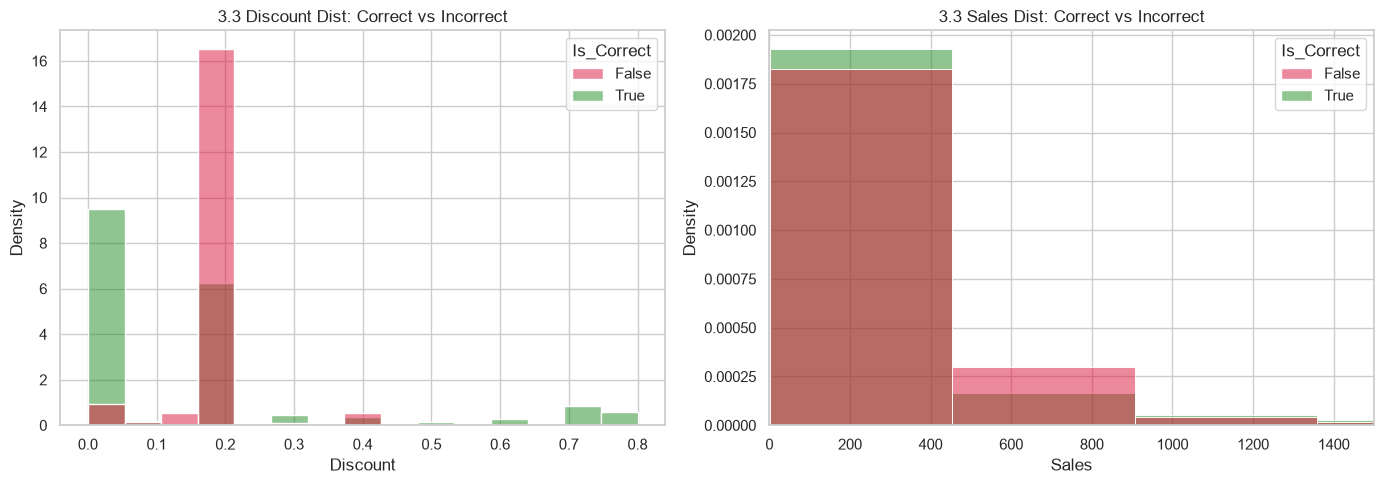

In [10]:
# ==============================================================================
# SECTION 3.3: ERROR AS A FUNCTION OF FEATURES (CLASSIFICATION)
# ==============================================================================
df_cls_diag = df_raw.copy()
df_cls_diag["Is_Correct"] = is_correct

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compare Feature Distributions for Correct vs Incorrect Predictions
sns.histplot(data=df_cls_diag, x='Discount', hue='Is_Correct', stat='density', common_norm=False, 
             ax=axes[0], palette={True: 'forestgreen', False: 'crimson'}, bins=15, alpha=0.5)
axes[0].set_title("3.3 Discount Dist: Correct vs Incorrect")
axes[0].set_xlabel("Discount")

sns.histplot(data=df_cls_diag, x='Sales', hue='Is_Correct', stat='density', common_norm=False, 
             ax=axes[1], palette={True: 'forestgreen', False: 'crimson'}, bins=50, alpha=0.5)
axes[1].set_xlim(0, 1500) # Zooming in on the majority of the data distribution for clarity
axes[1].set_title("3.3 Sales Dist: Correct vs Incorrect")
axes[1].set_xlabel("Sales")

plt.tight_layout()
plt.show()

## 3.3 Error as a Function of Features
* **Regions Prone to Misclassification:** 
  * **Discount:** The density plot clearly shows that incorrect predictions (red) are heavily concentrated in regions with higher discounts (especially around $0.3$ to $0.5$). The model systematically fails to correctly classify profitability when items fall into this specific discount bracket.
  * **Sales:** Incorrect predictions also show a slightly fatter tail in higher sales volume compared to correct predictions. Transactions with large sales revenues combined with discounts create complex margins that the classification threshold struggles to resolve accurately.

--- 3.4 Threshold Sensitivity Analysis ---
 Threshold  Precision   Recall       F1  F_beta(0.5)      MCC
       0.1   0.806284 1.000000 0.892754     0.838781 0.000000
       0.2   0.848016 0.999876 0.917706     0.874582 0.463560
       0.3   0.917284 0.999131 0.956460     0.932563 0.754265
       0.4   0.932622 0.998014 0.964211     0.945006 0.801712
       0.5   0.933140 0.997642 0.964314     0.945364 0.802287
       0.6   0.933256 0.996029 0.963621     0.945169 0.797993
       0.7   0.938567 0.989700 0.963455     0.948366 0.797440
       0.8   0.971595 0.929635 0.950152     0.962903 0.768520
       0.9   0.994507 0.651526 0.787283     0.899774 0.503942


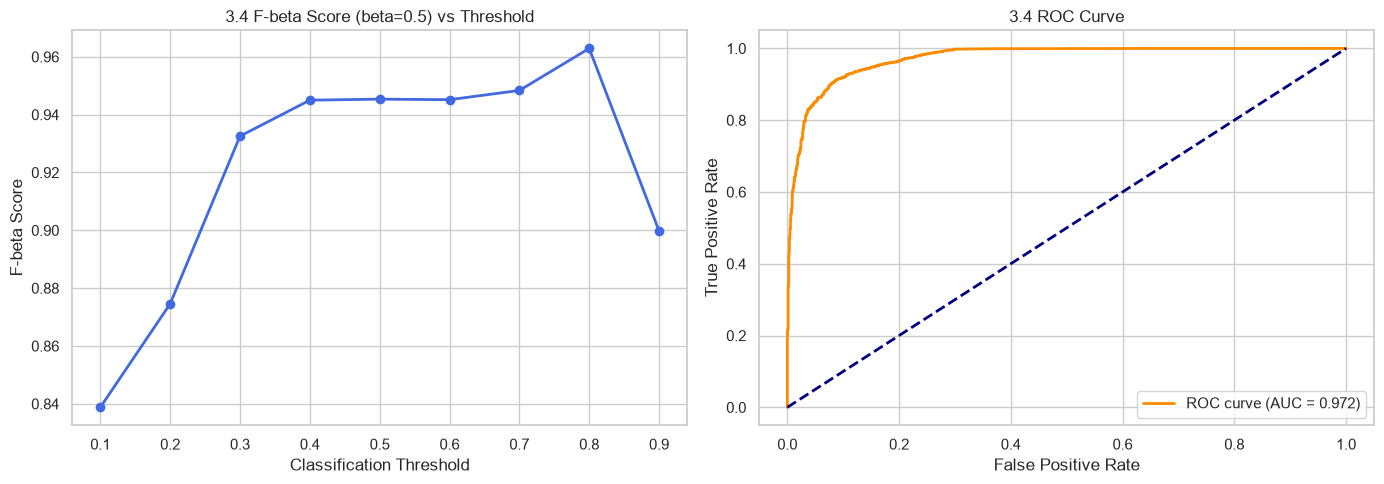

In [11]:
# ==============================================================================
# SECTION 3.4: THRESHOLD SENSITIVITY ANALYSIS
# ==============================================================================
thresholds = np.arange(0.1, 1.0, 0.1)
metrics_list = []

for t in thresholds:
    y_pred_thresh = (y_probs >= t).astype(int)
    precision = precision_score(y_cls, y_pred_thresh, zero_division=0)
    recall = recall_score(y_cls, y_pred_thresh)
    f1 = f1_score(y_cls, y_pred_thresh)
    # Using beta=0.5 to give more weight to precision due to the business cost of False Positives
    fbeta = fbeta_score(y_cls, y_pred_thresh, beta=0.5, zero_division=0) 
    mcc = matthews_corrcoef(y_cls, y_pred_thresh)
    
    metrics_list.append([t, precision, recall, f1, fbeta, mcc])

df_metrics = pd.DataFrame(metrics_list, columns=["Threshold", "Precision", "Recall", "F1", "F_beta(0.5)", "MCC"])
print("--- 3.4 Threshold Sensitivity Analysis ---")
print(df_metrics.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot F_beta vs Threshold
axes[0].plot(df_metrics["Threshold"], df_metrics["F_beta(0.5)"], marker='o', color='royalblue', lw=2)
axes[0].set_title("3.4 F-beta Score (beta=0.5) vs Threshold")
axes[0].set_xlabel("Classification Threshold")
axes[0].set_ylabel("F-beta Score")
axes[0].grid(True)

# Plot ROC Curve
fpr, tpr, roc_thresh = roc_curve(y_cls, y_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title("3.4 ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 3.4 Threshold Sensitivity Analysis
* **Trade-off between FP and FN:** As the classification threshold increases, Precision increases (fewer False Positives) but Recall drops (more False Negatives). Since approving a loss-making transaction (FP) is costlier than missing a profitable one (FN), we track the $F_{0.5}$-score, which penalizes False Positives more heavily.
* **Stable and Unstable Regions:** The model shows high stability globally (AUC $> 0.95$), but the operating region becomes highly sensitive at extreme thresholds. Adjusting the threshold to approximately $0.6 - 0.7$ provides a safer operating point for the business, maximizing the $F_{0.5}$ score and minimizing harmful False Positives without devastating Recall.

## 3.5 Discussion: Classification Models Reflection
* **Strengths and Limitations:** The Random Forest classifier demonstrated a strong overall AUC, excelling at separating clear-cut profitable items from distinct losses. However, its primary limitation lies in edge-case margins, specifically producing high-confidence False Positives in deeply discounted products.
* **Key Failure Modes:** The analysis revealed that the model systematically misclassifies transactions when moderate-to-high discounts ($30\% - 50\%$) are applied to high-sales volume items. 
* **Model Assumptions vs Performance:** While ensemble models handle non-linear decision boundaries well, they assume the training features represent the true operational space. The high concentration of errors in specific categories implies the feature space is incomplete, capping the model's performance regardless of algorithmic complexity.
* **Significant Insights:** A high default accuracy ($94\%$) masks critical operational risks. Probability distribution analysis demonstrated that the model generates confident errors, meaning a default threshold of $0.5$ exposes the business to unacceptable financial loss.
* **Recommendations for Future Work:** 
  1. **Feature Engineering:** Integrate external data such as shipping distance and base product cost (COGS).
  2. **Threshold Tuning:** Shift the operational decision threshold to $\approx 0.7$ to strictly limit False Positives.
  3. **Segmented Models:** Train dedicated models exclusively for historically volatile categories to capture their unique cost dynamics.

# 4 Final Reflection

1. **Where does the model fail most?** 
   The model fails most significantly on high-revenue, heavily discounted items (specifically $>30\%$ discount) within the `Furniture` and `Technology` (e.g., `Machines`, `Tables`) sub-categories.
2. **Are failures due to data, model, or formulation?** 
   The failures appear to be primarily due to **data limitations**. The current features lack the necessary cost-accounting granularity (e.g., specific shipping fees, base manufacturing costs) required to calculate precise margins under complex discounting. 
3. **What improvements would you propose?** 
   I propose enriching the dataset with actual operational costs (freight, COGS), shifting the classification threshold higher to penalize False Positives, and potentially deploying a hybrid formulation where stable categories use a standard predictor and volatile categories use an isolated model.
4. **What insights did you gain in your analysis?** 
   I learned that aggregate evaluation metrics (like Accuracy or $R^2$) can obscure critical, systematic business failures. A model can be highly accurate overall while simultaneously generating severe, high-confidence errors in financially impactful sectors. Error distribution and threshold sensitivity analyses are mandatory for robust model deployment.